# Running Simulations with the MIDA Head Phantom

## Introduction

The purpose of this notebook is to demonstrate how to run CT simulations using open-source head phantoms as a part of **Aim 1.3** with the [XCIST](https://github.com/xcist/main) CT simulation framework.

![](../project_aims.png)
*This notebook focuses on Aim 1.3, CT Dataset Generation Pipeline*

### Previous Work

Previously for the [pilot study](https://github.com/bnel1201/Virtual-Patient-CT-Simulations/blob/PedSilicoICH-Pilot/pedsilico-pilot.ipynb) we demonstrated inserting simple circular lesions into an XCAT head phantom using the [XCIST simulation framework](https://github.com/xcist). See their [Phys Med Bio article](https://iopscience.iop.org/article/10.1088/1361-6560/ac9174) for more.

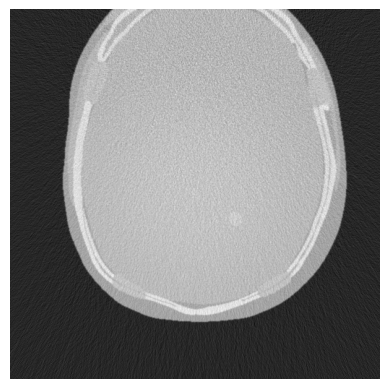

###  Why Virtual Imaging Trials?

Data driven methods like AI have enabled innovation in medical devices and clinical practice by leveraging large data sources to solve previously intractable problems in medical imaging including image reconstruction, segmentation and classification. However, any data driven method is at risk of bias and over fitting on sparse and noisey training sets and are liable to drift to changing data sources in production. Developing large, diverse high quality test sets is an important mitigation to model bias and drift but becomes challenging when considering including rare diseases and underrepresented groups such as pediatrics into device development and evaluation. In addition, pediatrics have special protections on data access further challenging their inclusing in training and testing datasets. Thus in silico modeling of patients, diseases, and imaging systems will be another essential mitigation factor enabling high quality labeled data where ground truth is known exactly and can be produced sustainably compared to traditional clinical trials and retrospective collection. 

This work aims to devloped in silico disease models of large vessel occlusions that can be modeled for pediatric evaluation of LVO cadt devices.


## Methods

### Working with `Phantoms`

Define the base healthy phantom head to be imaged

This notebook introduces running simulations with [MIDA head phantom](https://www.fda.gov/medical-devices/science-and-research-medical-devices/mida-multimodal-imaging-based-model-human-head-and-neck), a segmented MRI head model consisting of over 100 + segmented regions. The dataset is assumed to be downloaded in repository's root directory but you can modifiy `phantom_dir` accordingly if you have it else where

#### MIDA Head

In [1]:
!ls "../MIDA_Head_Phantom"

'MIDA RST page.url'   MIDA_slicer_preview.png   MIDA_v1.nii   MIDA_v1.txt


Thus to prepare the MIDA phantom for XCIST simulations we'll add a column called `xcist material` such that we can group several specific MIDA segmentation labels under a common, more broad label and assign it the same CT number. For example there are several anatomic regions in the MIDA phantom that are all primarily gray matter so we will assign them the xcist label of 'gray_matter' and given them a common CT number, see here for some reasonable CT numbers of materials: https://en.wikipedia.org/wiki/Hounsfield_scale#Values_for_different_body_tissues_and_material

*Note: these CT numbers are estimates and are just for making the volume fraction maps, they will differ in the final simulation depending on the chose kVp settings.*

Now we'll filter down the material look up table (LUT) just to materials with CT numbers that we've defined

Now reassign every voxel in the phantom to the defined CT numbers to make an approximate ground truth CT phantom:

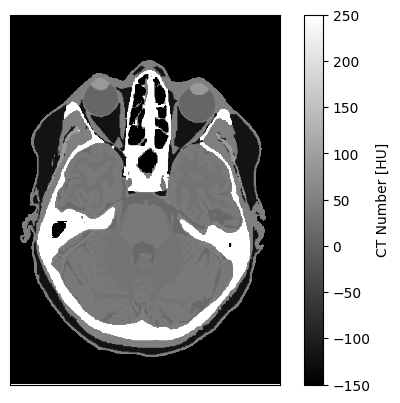

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt

from pedsilicoICH.ground_truth_definition.phantoms import MIDA_Head

from utils import ctshow

mida_dir = Path('../MIDA_Head_Phantom')
mida = MIDA_Head(mida_dir)
mida_shape = mida.get_CT_number_phantom().shape

im = ctshow(mida.get_CT_number_phantom()[250])
plt.colorbar(im, label='CT Number [HU]')

#### NIHPD Brain Atlas

See [02_MRI_brain_atlas_groundtruth.ipynb](02_MRI_brain_atlas_groundtruth.ipynb) for more.

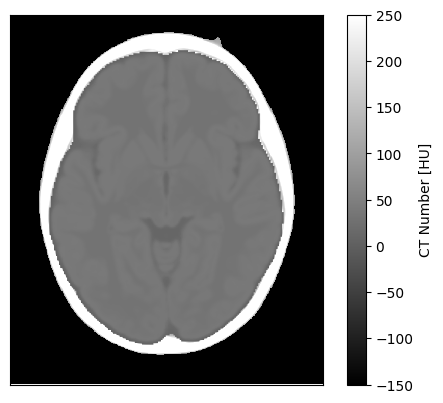

In [3]:
from pedsilicoICH.ground_truth_definition.phantoms import NIHPD_Head

nihpd_ages = [6.5, 9.0, 10.5, 11.5, 12.0, 15.75]
age = 6.5

nihpd_dir = Path('/gpfs_projects/brandon.nelson/pedsilicoICH/phantoms/NIHPD_Head_Phantom/')
nihpd = NIHPD_Head(nihpd_dir, age=age, shape=mida_shape)

im = ctshow(nihpd.get_CT_number_phantom()[250])
plt.colorbar(im, label='CT Number [HU]')

#### Select Phantom Based on Age

In [4]:
mida_age = 38  # add 38 as the median US adult age to represent MIDA, consider other identifiers when adding more patients
possible_ages = nihpd_ages + [mida_age] 
possible_ages

[6.5, 9.0, 10.5, 11.5, 12.0, 15.75, 38]

6.5


Text(0.5, 1.0, '6.5')

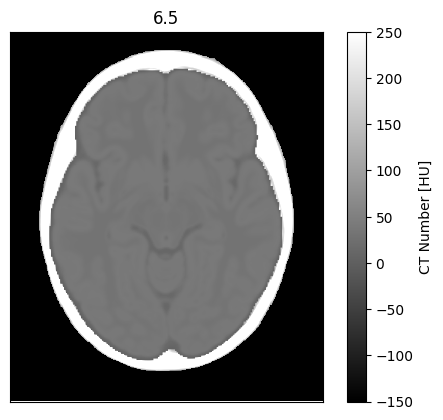

In [5]:
from random import choice

age = choice(possible_ages)
age = 6.5
print(age)

if age == mida_age:
    phantom = MIDA_Head(mida_dir)
else:
    phantom = NIHPD_Head(nihpd_dir, age=age, shape=mida_shape)

ground_truth = phantom.get_CT_number_phantom()

midslice = 2*ground_truth.shape[0]//3
im = ctshow(ground_truth[midslice])
plt.colorbar(im, label='CT Number [HU]')
plt.title(f'{age}')

In [6]:
phantom


        phantom class: NIHPD_Head
        age [yrs]: 6.5
        shape [voxels]: [389, 480, 406]
        size [mm]: [189. 233. 197.]
        
        Number of lesions: 0
        Lesion locations [voxel index (z, x, y)]: []
        Mass effect: False
        

#### Input Format for Running XCIST CT Simulations

According to the XCIST instructions for running CT simulations from [voxelized ground truth phantoms](https://github.com/xcist/phantoms-voxelized), XCIST requires volume fraction maps, see [their github for examples](https://github.com/xcist/phantoms-voxelized/tree/main/CatSimLogo_1024). XCIST provides [example code](https://github.com/xcist/phantoms-voxelized/blob/main/DICOM_to_voxelized/DICOM_to_voxelized_phantom.py) of how to convert CT images into these ground truth volume fraction maps.

The `Scanner` class was created as a wrapper object to simplify loading voxelized numpy ndarrays into XCIST siumulations, see the doc string for more details on use and parameters:

In [7]:
from pedsilicoICH.image_acquisition import Scanner

My goal is to reproduce the steps done here: [open source XCIST demo](https://github.com/bnel1201/XCIST_demo/blob/main/opensource_peds_demo.ipynb) of assigning each labeled anatomy to an xcist material for converting to linear attenuation units. Note that the `Scanner` constructor has two required inputs:

1. a voxelized `phantom` input in units of CT numbers
2. voxel dimensions in [mm]

The MIDA phantom consists of many segmented regions, more than we reasonably need for a CT simulation:

Now interactively view the ground truth phantom to inspect it:

In [8]:
from utils import scrollview
scrollview(ground_truth)

interactive(children=(IntSlider(value=194, description='idx', max=388), Output()), _dom_classes=('widget-inter…

#### Introduce Random Affine Augmentations

To simulate a small amount of patient positioning variability

In [9]:
from monai.transforms import RandAffine
import numpy as np
randaffine = RandAffine(prob=0.5, rotate_range = [np.pi/4, np.pi/20, np.pi/20], translate_range=[10, 10, 10], scale_range=[0.1, 0.1, 0.1], padding_mode="border")

scrollview(randaffine(ground_truth[None])[0])

interactive(children=(IntSlider(value=194, description='idx', max=388), Output()), _dom_classes=('widget-inter…

TODO: if CT numbers seem off, I can look into updating the thresholds in the [config file](https://github.com/xcist/phantoms-voxelized/blob/main/DICOM_to_voxelized/DICOM_to_voxelized_example_head.cfg) appropriately to get the best match in CT numbers (could do something like grab the unique values since I'm starting from ground truth, they are [currently configured](https://github.com/brandonjnelsonFDA/PedSilicoICH/blob/master/src/pedsilicoICH/ground_truth_definition/phantoms.py#L23) for abdominal imaging, rather than head.

Example of [normal brain CT](https://nbia.cancerimagingarchive.net/viewer/?study=1.3.6.1.4.1.14519.5.2.1.3098.5025.922017993220231365363448902707&series=1.3.6.1.4.1.14519.5.2.1.3098.5025.127673560102649811051571885155&token=eyJhbGciOiJIUzI1NiIsInR5cCIgOiAiSldUIiwia2lkIiA6ICJkZGFhMGY3YS1kZTBmLTRkYWQtYjM1ZS05MjljYjBiMTY3YjgifQ.eyJleHAiOjE3MDQ0MDA4NDYsImlhdCI6MTcwNDM5MzY0NiwianRpIjoiZDU4YTI0M2YtNGQwZi00MjljLTg0NDQtMGI5MjJjNzUzNWQ0IiwiaXNzIjoiaHR0cHM6Ly9rZXljbG9hay5kYm1pLmNsb3VkL2F1dGgvcmVhbG1zL1RDSUEiLCJhdWQiOiJhY2NvdW50Iiwic3ViIjoiZjowMTliNTYzNC1kYWJkLTQyMTEtYTQxZC03MjNjNDRhZmNmZmQ6bmJpYV9ndWVzdCIsInR5cCI6IkJlYXJlciIsImF6cCI6Im5iaWEiLCJzZXNzaW9uX3N0YXRlIjoiYzc5OTIxMTItZjcyYS00OWY5LWI0ZTMtOWY3ZTFmN2I0NzQ5IiwiYWNyIjoiMSIsImFsbG93ZWQtb3JpZ2lucyI6WyJodHRwczovL3NlcnZpY2VzLmNhbmNlcmltYWdpbmdlYXJjaGl2ZS5uZXQiLCJodHRwczovL25iaWEuY2FuY2VyaW1hZ2luZ2VhcmNoaXZlLm5ldCIsImh0dHBzOi8vd3d3LmNhbmNlcmltYWdpbmdlYXJjaGl2ZS5uZXQiLCIqIiwiaHR0cDovL3RjaWEtbmJpYS0yLmFkLnVhbXMuZWR1OjQ1MjEwIiwiaHR0cHM6Ly9jYW5jZXJpbWFnaW5nZWFyY2hpdmUubmV0IiwiaHR0cDovL3RjaWEtbmJpYS0xLmFkLnVhbXMuZWR1OjQ1MjEwIiwiaHR0cHM6Ly9wdWJsaWMuY2FuY2VyaW1hZ2luZ2VhcmNoaXZlLm5ldCJdLCJyZWFsbV9hY2Nlc3MiOnsicm9sZXMiOlsib2ZmbGluZV9hY2Nlc3MiLCJkZWZhdWx0LXJvbGVzLXRjaWEiLCJ1bWFfYXV0aG9yaXphdGlvbiJdfSwicmVzb3VyY2VfYWNjZXNzIjp7ImFjY291bnQiOnsicm9sZXMiOlsibWFuYWdlLWFjY291bnQiLCJtYW5hZ2UtYWNjb3VudC1saW5rcyIsInZpZXctcHJvZmlsZSJdfX0sInNjb3BlIjoib3BlbmlkIHByb2ZpbGUgZW1haWwiLCJzaWQiOiJjNzk5MjExMi1mNzJhLTQ5ZjktYjRlMy05ZjdlMWY3YjQ3NDkiLCJlbWFpbF92ZXJpZmllZCI6dHJ1ZSwibmFtZSI6Ik5CSUEgR3Vlc3QiLCJwcmVmZXJyZWRfdXNlcm5hbWUiOiJuYmlhX2d1ZXN0IiwiZ2l2ZW5fbmFtZSI6Ik5CSUEiLCJmYW1pbHlfbmFtZSI6Ikd1ZXN0IiwiZW1haWwiOiJuYmlhX2d1ZXN0QGNhbmNlcmltYWdpbmdhcmNoaXZlLm5ldCJ9.q7c8o4AZK8cnCMYmZD_TjGvGyLIAZBysMJNIVV3agrE) for reference:

### Adding lesions

Some simple analytical geometric lesions are included in the module `lesion_insertion`

Some hemorrhages develop hypoattenuating edema or fluid build up following healhing.

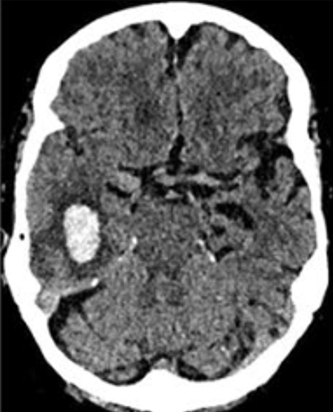

We can add in annuli of different intensitys mimicing lesions by specifying a list of radii and intensitys:

In [10]:
from utils import show_lesions

#### Epidural

In [11]:
phantom.insert_lesion?

Signature:
phantom.insert_lesion(
    lesion_type,
    volume=10,
    intensity=50,
    init_slice=None,
    mass_effect=False,
    seed=None,
    **kwargs,
)
Docstring:
inserts lesion of `lesion_type` into phantom array

:param lesion_type: str, options include
    ['round', 'epidural', 'subdural'],
    see associated methods `add_round_lesion`, `_add_dural_lesion`
:param volume: in mL, volume of the lesion
:param intensity: lesion CT number in HU
:param init_slice: optional, slice to add dural_lesions to
:param meass_effect: optional, bool whether to apply mass effect
    processing to displace brain tissue following lesion insertion
:param edema: optional, bool or int. whether to add a ring of low
    contrast, 10 HU, edema around the lesion, currently only
    implemented for sphere
:param seed: optional, int specify seed for reproducible lesion
    insertion, otherwise random

return img_w_lesion, lesion_image, lesion_coords
File:      ~/Dev/PedSilicoICH/src/pedsilicoICH/ground_tr

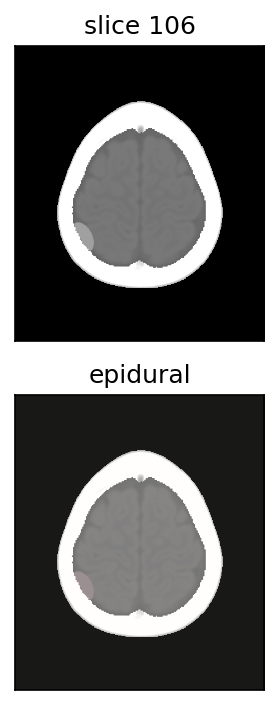

In [12]:
volume = 2 # mL
intensity = 100

phantom = NIHPD_Head(nihpd_dir, age=age, shape=mida_shape)
phantom.insert_lesion('epidural', volume=volume, intensity=intensity) # ['round', 'epidural', 'subdural'
show_lesions(phantom)

In [ ]:
%%time
seed = 42
phantom = NIHPD_Head(nihpd_dir, age=age, shape=mida_shape)
phantom.insert_lesion('epidural', volume=40, mass_effect=0.8, seed=seed)
ctshow(phantom._phantom[phantom._lesion_coords[0][0]])
phantom_me_image = phantom._phantom[phantom._lesion_coords[0][0]]

In [ ]:
%%time
phantom = NIHPD_Head(nihpd_dir, age=age, shape=mida_shape)
phantom.insert_lesion('epidural', volume=40, mass_effect=0, seed=seed)
ctshow(phantom._phantom[phantom._lesion_coords[0][0]])
phantom_no_me_image = phantom._phantom[phantom._lesion_coords[0][0]]

In [ ]:
plt.imshow(phantom_me_image - phantom_no_me_image, vmin=-20, vmax=20)

In [ ]:
from pedsilicoICH.ground_truth_definition.phantoms import get_transformation_src_dst
from pedsilicoICH.lesion_definition import warp_slice

phantom = NIHPD_Head(nihpd_dir, age=age, shape=mida_shape)
img_w_lesion, lesion_vol, (z, x, y) = phantom._add_dural_lesion(lesion_type='epidural', volume=10, intensity=100, seed=42)

boundary = phantom.get_skull_map()
img = phantom.get_CT_number_phantom()
def show_mass_effect_strength(strength = 0.5):
    src, dst = get_transformation_src_dst(lesion_vol[z], strength)
    dst_coords = np.argwhere(dst)
    src_coords = np.argwhere(src)
    if strength > 0:
        warped = warp_slice(img[z],
                            boundary[z],
                            src_coords, dst_coords)
        warped[lesion_vol[z]] = img_w_lesion[z][lesion_vol[z]].copy()
    else:
        warped = img_w_lesion.copy()
    f, axs = plt.subplots(1, 2)
    ctshow(img_w_lesion[z], 'brain', fig=f, ax=axs[0])
    axs[0].imshow(src, alpha=0.2, cmap='Reds')
    axs[0].set_title('src')

    ctshow(warped, 'brain', fig=f, ax=axs[1])
    axs[1].imshow(src, alpha=0.2, cmap='Reds')
    axs[1].imshow(dst, alpha=0.2, cmap='Reds')
    axs[1].set_title(f'dst, strength: {strength}')
    f.show()

show_mass_effect_strength()

In [ ]:
from ipywidgets import interact, IntSlider
interact(lambda idx: show_mass_effect_strength(idx/10), idx=IntSlider(value=5, min=0,max=10))

#### Round

In [ ]:
phantom.add_round_lesion?

In [ ]:
phantom = NIHPD_Head(nihpd_dir, age=age, shape=mida_shape)
phantom.insert_lesion('round', volume, intensity=intensity, complexity=3, edema=7, eccentricity=0.9) 
show_lesions(phantom)

##### Mass Effect

In [ ]:
%%time
seed = 42
phantom = NIHPD_Head(nihpd_dir, age=age, shape=mida_shape)
phantom.insert_lesion('round', volume=40, eccentricity=0.5, edema=False, mass_effect=0.8, seed=seed)
ctshow(phantom._phantom[phantom._lesion_coords[0][0]])
phantom_me_image = phantom._phantom[phantom._lesion_coords[0][0]]

In [ ]:
%%time
phantom = NIHPD_Head(nihpd_dir, age=age, shape=mida_shape)
phantom.insert_lesion('round', volume=40, eccentricity=0.5, edema=False, mass_effect=0, seed=seed)
ctshow(phantom._phantom[phantom._lesion_coords[0][0]])
phantom_no_me_image = phantom._phantom[phantom._lesion_coords[0][0]]

In [ ]:
plt.imshow(phantom_me_image - phantom_no_me_image, vmin=-20, vmax=20)
plt.colorbar()

Notice that certain parameters such as adding edema and mass effect increase computation times

In [ ]:
%%time
phantom = NIHPD_Head(nihpd_dir, age=age, shape=mida_shape)
phantom.insert_lesion('round', volume=40, eccentricity=0.5, edema=True, mass_effect=0)
ctshow(phantom._phantom[phantom._lesion_coords[0][0]])

In [ ]:
from pedsilicoICH.ground_truth_definition.phantoms import get_transformation_src_dst
from pedsilicoICH.lesion_definition import warp_slice

phantom = NIHPD_Head(nihpd_dir, age=age, shape=mida_shape)
img_w_lesion, lesion_vol, (z, x, y) = phantom.add_round_lesion(volume=10, intensity=100,
                                                            eccentricity=0, seed=42)
boundary = phantom.get_skull_map()
img = phantom.get_CT_number_phantom()
def show_mass_effect_strength(strength = 0.5):
    src, dst = get_transformation_src_dst(lesion_vol[z], strength)
    dst_coords = np.argwhere(dst)
    src_coords = np.argwhere(src)
    if strength > 0:
        warped = warp_slice(img[z],
                            boundary[z],
                            src_coords, dst_coords)
        warped[lesion_vol[z]] = img_w_lesion[z][lesion_vol[z]].copy()
    else:
        warped = img_w_lesion.copy()
    f, axs = plt.subplots(1, 2)
    ctshow(img_w_lesion[z], 'brain', fig=f, ax=axs[0])
    axs[0].imshow(src, alpha=0.2, cmap='Reds')
    axs[0].set_title('src')

    ctshow(warped, 'brain', fig=f, ax=axs[1])
    axs[1].imshow(src, alpha=0.2, cmap='Reds')
    axs[1].imshow(dst, alpha=0.2, cmap='Reds')
    axs[1].set_title(f'dst, strength: {strength}')
    f.show()

show_mass_effect_strength()

In [ ]:
from ipywidgets import interact, IntSlider
interact(lambda idx: show_mass_effect_strength(idx/10), idx=IntSlider(value=5, min=0,max=10))

#### Subdural

In [ ]:
phantom = NIHPD_Head(nihpd_dir, age=age, shape=mida_shape)
phantom.insert_lesion('subdural', volume, intensity=intensity) 
show_lesions(phantom)

In [ ]:
phantom = NIHPD_Head(nihpd_dir, age=age, shape=mida_shape)
img_w_lesion, lesion_vol, (z, x, y) = phantom._add_dural_lesion(lesion_type='subdural', volume=10, intensity=100, seed=42)

boundary = phantom.get_skull_map()
img = phantom.get_CT_number_phantom()
def show_mass_effect_strength(strength = 0.5):
    src, dst = get_transformation_src_dst(lesion_vol[z], strength)
    dst_coords = np.argwhere(dst)
    src_coords = np.argwhere(src)
    if strength > 0:
        warped = warp_slice(img[z],
                            boundary[z],
                            src_coords, dst_coords)
        warped[lesion_vol[z]] = img_w_lesion[z][lesion_vol[z]].copy()
    else:
        warped = img_w_lesion.copy()
    f, axs = plt.subplots(1, 2)
    ctshow(img_w_lesion[z], 'brain', fig=f, ax=axs[0])
    axs[0].imshow(src, alpha=0.2, cmap='Reds')
    axs[0].set_title('src')

    ctshow(warped, 'brain', fig=f, ax=axs[1])
    axs[1].imshow(src, alpha=0.2, cmap='Reds')
    axs[1].imshow(dst, alpha=0.2, cmap='Reds')
    axs[1].set_title(f'dst, strength: {strength}')
    f.show()

show_mass_effect_strength()

In [ ]:
from ipywidgets import interact, IntSlider
interact(lambda idx: show_mass_effect_strength(idx/10), idx=IntSlider(value=5, min=0,max=10))

#### Multiple

In [ ]:
phantom = NIHPD_Head(nihpd_dir, age=age, shape=mida_shape)
contrast = 100
phantom.insert_lesion('round', volume, intensity=intensity) 
phantom.insert_lesion('subdural', volume, intensity=intensity) 
phantom.insert_lesion('epidural', volume, intensity=intensity) 

show_lesions(phantom)

In [ ]:
phantom

In [ ]:
lesions = phantom.get_lesion_mask()
lesions.shape

`phantom._lesion_coords` is a list of (z,x,y) coordinates of the inserted lesion, you can check the `len` to see how many lesions have been inserted, thus by indexing `[0][0]` we are taking the z index of the first lesion.

In [ ]:
phantom._lesion_coords

Note that rerunning the following cell, you can keep adding lesions to a phantom

In [ ]:
add_positioning_augmentation = True
if add_positioning_augmentation:
    positioning_transform = RandAffine(prob=0.5, rotate_range = [np.pi/4, np.pi/20, np.pi/20], translate_range=[10, 10, 10], scale_range=[0.1, 0.1, 0.1], padding_mode="border")
else:
    positioning_transform = RandAffine(prob=0)

phantom.apply_transform(positioning_transform)

In [ ]:
phantom.apply_transform(positioning_transform)
show_lesions(phantom)

Note: there is some misalignment of the mask and image when there are more than 1 lesion, the first lesion mask gets transformed, but the second is untouched. This is a TODO to fix this such that all inserted lesion masks get transformed.

### Now put it together into a loader

And show the new `mass_effect` option!

In [ ]:
from pedsilicoICH.ground_truth_definition.phantoms import load_phantom

phantom = load_phantom(age=age)
phantom.insert_lesion('epidural', mass_effect=False, seed=6)
show_lesions(phantom)

In [ ]:
phantom = load_phantom(age=age)
phantom.insert_lesion('round', volume=10, eccentricity=0)
show_lesions(phantom)

In [ ]:
phantom = load_phantom(age=age)
phantom.insert_lesion('round', volume=10, eccentricity=0.5, edema=True)
show_lesions(phantom)

In [ ]:
phantom = load_phantom(age=age)
phantom.insert_lesion('round', volume=20, eccentricity=1, edema=True)
show_lesions(phantom)

In [ ]:
from utils import center_crop, center_crop_like

### Running CT Scans: the `Scanner` class

In [ ]:
phantom.patient_name = 'small phantom with lesion'
scanner = Scanner(phantom)
scanner

Based on the size of the phantom we can get an estimate of how many scans are required to cover it, from there we can either keep the full range or modify accordingly, we can also set the table speed if we want to use helical acquisition for faster scan times (although I don't yet have helical acquisitions figured out yet, see [github issue](https://github.com/xcist/main/issues/73) on this and the [helical mode example](https://github.com/xcist/main/blob/master/gecatsim/examples/Sim_Sample_Helical.py).

In [ ]:
scanner.scout_view(table_speed='Intermediate')

In [ ]:
suggested_start_mm, suggested_end_mm = scanner.recommend_scan_range()
print(f'recommended range: ({suggested_start_mm}, {suggested_end_mm}) mm')
scanner.scout_view(startZ=suggested_start_mm, endZ=suggested_end_mm)

Arrow indicates table direction, it translates here with the base of the skull moving vertically

For a quick test let's do 1 scan so adjust the extent accordingly

Convert the lesion Z level from pixel coordinates to the table coordinates so we can selectively scan around the lesion for faster run times for this demo.

In [ ]:
lesion_level_mm = (phantom.get_CT_number_phantom().shape[0]/2 - phantom._lesion_coords[0][0])*phantom.dz
center = lesion_level_mm
width = 7

startZ = center - width//2
endZ = startZ + width

print(center, startZ, endZ)
scanner.scout_view(startZ=startZ, endZ=endZ, table_speed=0)

Look at how much faster we can scan with helical mode!

Still unclear how to do recon in helical mode...

there is 
```python
scanner.xcist.cfg.recon.reconType = 'helical_equiAngle'
```

as discussed here: https://github.com/xcist/main/issues/61#issuecomment-1955840993



In [ ]:
scanner.run_scan(kVp=120, mA=200, startZ=startZ, endZ=endZ, views=100)

In [ ]:
scanner.run_recon(kernel='soft')

In [ ]:
scanner.phantom.gm_HU, scanner.phantom.wm_HU

In [ ]:
scrollview(scanner.recon)

In [ ]:
ctshow(scanner.recon, 'brain')

In [ ]:
scanner.get_lesion_mask?

In [ ]:
mask = scanner.get_lesion_mask(startZ=startZ, endZ=endZ)
mask.shape

In [ ]:
ctshow(scanner.recon.mean(axis=0))
plt.imshow(mask.mean(axis=0), cmap='Reds', alpha=0.2)
plt.show()

In [ ]:
mAs = [20, 200]
mA_recons = []
for mA in mAs:
    scanner.run_scan(mA=mA, startZ=startZ, endZ=endZ, views=100)
    scanner.run_recon(sliceThickness=1, kernel='soft')
    mA_recons.append(scanner.recon)

In [ ]:
ctshow(np.concatenate(list(map(lambda x: center_crop_like(x[0], mA_recons[0][0]), mA_recons)), axis=1), window='brain')

In [ ]:
kVps = [80, 140]
kVp_recons = []
for kVp in kVps:
    scanner.run_scan(kVp=kVp, mA=200, startZ=startZ, endZ=endZ, views=100)
    scanner.run_recon(sliceThickness=1, kernel='soft')
    kVp_recons.append(scanner.recon)

In [ ]:
ctshow(np.concatenate([center_crop(kVp_recons[0][0]), center_crop_like(kVp_recons[1][0], kVp_recons[0][0])], axis=1), window='brain')

In [ ]:
standard_recon = scanner.recon

In [ ]:
scanner.run_scan(kVp=120, mA=200, startZ=startZ, endZ=endZ, views=100)

In [ ]:
scanner.run_recon(sliceThickness=1, kernel='standard')
standard_recon = scanner.recon

scanner.run_recon(sliceThickness=5, kernel='soft')
soft_recon = scanner.recon

In [ ]:
ctshow(np.concatenate([center_crop(standard_recon[0]), center_crop_like(soft_recon[0], standard_recon[0])], axis=1), window='brain')

### Viewing Mass Effect in Image Data

In [ ]:
scanner = Scanner(phantom)
scanner.run_scan(mA=500, startZ=startZ, endZ=endZ, views=100)
scanner.run_recon(sliceThickness=5, kernel='soft')

In [ ]:
scanner_me = Scanner(phantom_me)
scanner_me.run_scan(mA=500, startZ=startZ, endZ=endZ, views=100)
scanner_me.run_recon(sliceThickness=1)

In [ ]:
scanner_me.run_recon(sliceThickness=1, kernel='soft')
scanner.run_recon(sliceThickness=1, kernel='soft')

In [ ]:
scrollview(scanner_me.recon)

In [ ]:
scrollview(scanner_me.recon.transpose(2, 0, 1))

In [ ]:
scanner.projections[:,0,2:].shape

In [ ]:
plt.figure(figsize=(3,2.5), dpi=150)
plt.imshow(scanner.projections[:, 4, :], cmap='gray', extent=[0, 500, 0, 360])
plt.colorbar(label='x-ray attenuation')
plt.xlabel('Detector Column')
plt.ylabel('View Angle [degrees]')

In [ ]:
f, axs = plt.subplots(1, 2, dpi=150, tight_layout=True, figsize=(5,8))

idx = 258
no_mass_effect = center_crop(phantom.get_CT_number_phantom()[idx])
mass_effect = center_crop_like(phantom_me.get_CT_number_phantom()[idx], phantom.get_CT_number_phantom()[idx])
ctshow(np.concatenate([no_mass_effect, mass_effect]), fig=f, ax=axs[0])
vline = 172
vline_y = 850
axs[0].vlines(vline, 0, vline_y, color='black', linestyle='--')

no_mass_effect_recon = center_crop(scanner.recon[0])
mass_effect_recon = center_crop_like(scanner_me.recon[0], scanner.recon[0])

ctshow(np.concatenate([no_mass_effect_recon, mass_effect_recon]), 'brain', fig=f, ax=axs[1])
axs[1].vlines(vline, 0, vline_y-20, color='black', linestyle='--')

In [ ]:
scanner.run_recon(sliceThickness=1)

scanner.xcist.cfg.recon.reconType = 'helical_equiAngle'
scanner.xcist.cfg.recon.reconType

scanner.xcist.cfg.recon.sliceThickness = 1
scanner.xcist.cfg.recon.sliceCount = int(scanner.scan_width / scanner.xcist.cfg.recon.sliceThickness)
scanner.run_recon(sliceCount=40)

In [ ]:
scrollview(scanner.recon)

In [ ]:
scrollview(scanner.projections.transpose(1,0,2), (4, 2))

In [ ]:
from monai.transforms import Affine
rotate = Affine(rotate_params=np.deg2rad(45), padding_mode='border')
phantom.apply_transform(rotate)
img_transform = phantom.get_CT_number_phantom()
ctshow(img_transform[250])

In [ ]:
scanner.phantom._lesion[0].shape

In [ ]:
scanner.get_lesion_mask?

In [ ]:
mask = scanner.get_lesion_mask(startZ=startZ, endZ=endZ)

In [ ]:
idx = 4
f, axs = plt.subplots(1, 2, dpi=150)
ctshow(scanner.recon[idx], fig=f, ax=axs[0])
ctshow(scanner.recon[idx], fig=f, ax=axs[1])
axs[1].imshow(mask[idx], alpha=0.15, cmap='Reds')
axs[0].set_title('CT Image')
axs[1].set_title('Lesion Mask Overlay')

In [ ]:
vol_mm3 = np.prod(scanner.phantom.spacings)*mask.sum()
vol_ml = vol_mm3/1000
vol_ml

#### Writing to Dicom

In [ ]:
fnames = scanner.write_to_dicom(fname = Path(scanner.phantom.patient_name) / 'dicoms' / f'{scanner.phantom.patient_name}.dcm')
fnames

#### Read in Results

In [ ]:
from pedsilicoICH.image_acquisition import read_dicom
vol = np.stack([read_dicom(o) for o in fnames])
vol.shape

In [ ]:
hi_dose = scanner.recon

In [ ]:
im = ctshow(hi_dose[-1]+20, 'brain')
plt.colorbar(im)

### Organize it into Study object

The `Study` object holds both the patient `Phantom` instance and the scanner `Scanner` instance and stores the relevant scan details

In [ ]:
startZ = 0
endZ = 50
scanner.scout_view(startZ=startZ, endZ=endZ)

In [ ]:
from pedsilicoICH.pipeline import Study, run_study
study = Study(scanner, 'pilot')
study

In [ ]:
ctshow(phantom.get_CT_number_phantom()[phantom._lesion_coords[0][0]])

In [ ]:
startZ, endZ

In [ ]:
study.run_study('test', kVp=120, mA=500, views=100, zspan=(startZ, endZ))

In [ ]:
study.metadata

In [ ]:
ctshow(study.scanner.recon[10], 'brain')

In [ ]:
study.images.shape, study.lesion.shape

In [ ]:
ctshow(study.images)
plt.imshow(study.lesion[0], cmap='Reds', alpha=0.1)

In [ ]:
study.metadata

In [ ]:
show_lesions(study.phantom)

In [ ]:
study = run_study('pilot', views=100, zspan = (0, 14), seed=42)
study.metadata

In [ ]:
from utils import ctshow
ctshow(study.images[13], 'temporal bones')

In [ ]:
ctshow(study.images[round(study.lesion_coords[0])])
plt.imshow(study.lesion[round(study.lesion_coords[0])], cmap='Reds', alpha=0.1)

In [ ]:
scrollview(study.scanner.recon)

In [ ]:
from pedsilicoICH.pipeline import run_study

## Rescan at a lower dose

In [ ]:
mA = 500/10
mA

In [ ]:
study.run_study('test', mA=mA, zspan=(startZ, endZ), views=100)

In [ ]:
lo_dose = study.scanner.recon

In [ ]:
study.scanner.recon

In [ ]:
scrollview(lo_dose)

In [ ]:
f, ax = plt.subplots(dpi=150)
im = ctshow(np.concatenate([hi_dose[-1], lo_dose[-1]], axis=1)+20, 'brain', fig=f,ax=ax)
plt.colorbar(im)
plt.title(f'Hi Dose 500 mA | Lo Dose {mA} mA') 

## Now Low kV

In [ ]:
study.run_study('test', mA=500, kVp=80, zspan=(startZ, endZ), views=100)

In [ ]:
scanner.run_recon(fov=250)
lo_kV = scanner.recon

In [ ]:
scrollview(lo_kV)

In [ ]:
f, ax = plt.subplots(dpi=150)
im = ctshow(np.concatenate([hi_dose[2], lo_kV[2]], axis=1)+20, 'soft tissues', fig=f,ax=ax)
plt.colorbar(im)
plt.title('120 kV | 80 kV') 

### Misc

There should be a better way to do helical to cover more brain fast but for now I dont know how to do it...

scanner.xcist.cfg.protocol.viewCount = 500
scanner.xcist.protocol.stopViewId = scanner.xcist.cfg.protocol.startViewId+scanner.xcist.cfg.protocol.viewCount-1

scanner.xcist.cfg.protocol.rotationTime

scanner.xcist.cfg.protocol.viewsPerRotation = 50

scanner.xcist.cfg.protocol.tableSpeed = 1

nrviews = scanner.xcist.cfg.protocol.viewCount
zshifts = np.arange(nrviews)*scanner.xcist.cfg.protocol.tableSpeed*scanner.xcist.cfg.protocol.rotationTime/scanner.xcist.cfg.protocol.viewsPerRotation
zshifts.shape

zshifts[0], zshifts[-1]

scanner.xcist.run_all()

scanner.xcist.cfg.recon.sliceCount = 40
scanner.xcist.cfg.recon.sliceThickness = 1

from gecatsim.reconstruction.pyfiles import recon
recon.recon(scanner.xcist.cfg)

from dxcist.xcist_sims import get_reconstructed_data
test_helical_recon = get_reconstructed_data(scanner.xcist)
test_helical_recon.shape

scrollview(test_helical_recon)

Has something to do with setting the zshift [see here](https://github.com/xcist/main/blob/4d0e50f016558c4bb64efd413d594925d0f00570/gecatsim/dose/pyfiles/catdoserecon.py#L116). This would make it easier to redo the reconstruction across a whole volume

In [ ]:
scrollview(study.images)

In [ ]:
scrollview(study.images.transpose(2, 0, 1))

## Exploring Table Speeds and Helical Recon

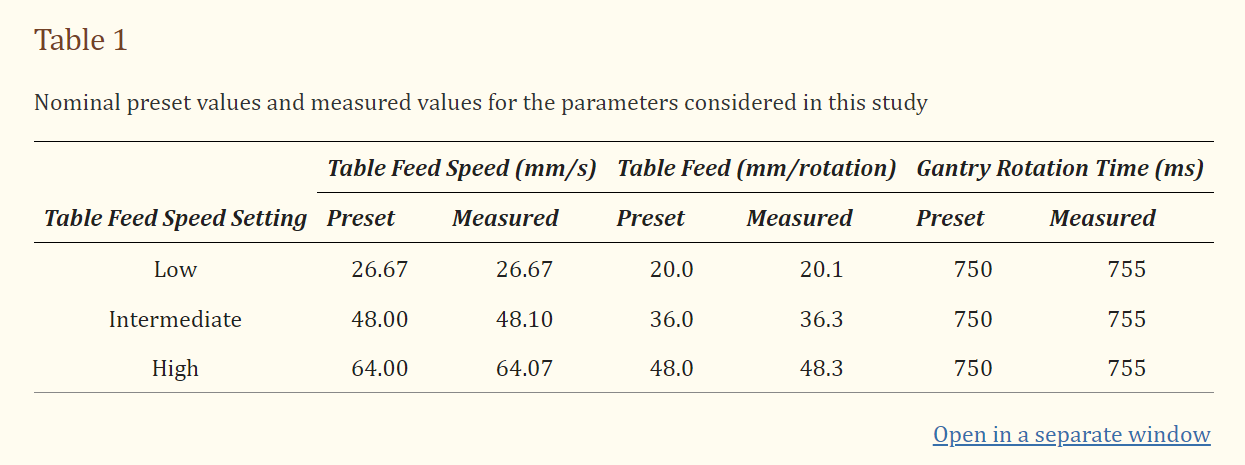

https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5711061/

In [ ]:
table_speed = 48 # medium, mm/s

In [ ]:
table_speed = {'Low': 26.67, 'Intermediate': 48, 'High': 64} # https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5711061/

Params to change: 1. views per rotation, 2. table speed, 3. total scan length

In [ ]:
scanner.xcist.cfg.protocol.viewsPerRotation = 100
scanner.xcist.cfg.protocol.tableSpeed = table_speed['Intermediate']
scanner.total_scan_length, scanner.xcist.cfg.protocol.tableSpeed, scanner.xcist.cfg.protocol.viewsPerRotation

Don't edit below, these are the calculations

In [ ]:
zcoverage_per_scan = scanner.xcist.cfg.protocol.rotationTime * scanner.xcist.cfg.protocol.tableSpeed
rotations_required = scanner.total_scan_length / zcoverage_per_scan
zcoverage_per_scan, rotations_required

In [ ]:
scanner.xcist.cfg.protocol.tableSpeed = 0
print(len(scanner.calculate_start_positions()))

scanner.xcist.cfg.protocol.tableSpeed = table_speed['Low']
print(len(scanner.calculate_start_positions()))

scanner.xcist.cfg.protocol.tableSpeed = table_speed['Intermediate']
print(len(scanner.calculate_start_positions()))

scanner.xcist.cfg.protocol.tableSpeed = table_speed['High']
print(len(scanner.calculate_start_positions()))

In [ ]:
scanner.xcist.cfg.protocol.viewCount = np.ceil(scanner.xcist.cfg.protocol.viewsPerRotation*rotations_required).astype(int)
scanner.xcist.cfg.protocol.stopViewId = scanner.xcist.cfg.protocol.startViewId + scanner.xcist.cfg.protocol.viewCount - 1
scanner.xcist.cfg.protocol.stopViewId 

In [ ]:
scanner.xcist.cfg.protocol.viewCount, scanner.xcist.cfg.protocol.viewsPerRotation, scanner.xcist.protocol.startZ

In [ ]:
scanner.xcist.protocol.tableSpeed

In [ ]:
scanner.xcist.run_all()

There are viewer aliasing streaks in the full scan

## TODOS

1. [ ] fix water atten value such that CT numbers are correct (currently a small negative bias, eg brain rois around -20 HU when  they should be +20 HU)
2. [ ] Merge MIRT and CATSim as different subclasses of Scanner so its easy to switch between the two (the first step of making a ground truth phantom with attenuation coefficients is the same)
   - I don't think MIRT is going to work with oct2py because the [wtfmex](https://web.eecs.umich.edu/~fessler/irt/irt/mex/oct/mi64/) compiled matlab/octave file gives en invalid ELF header, which indicates it needs to be recompiled and I dont have access to the source code
   - It looks like there is good progress at [Julia Image Recon](https://github.com/JuliaImageRecon), however CT examples are still missing.  I do not need another backend, XCIST is fine for now and is widely use.
3. [ ] Fork [xcist](https://github.com/xcist/main) and make that the new dxcist that i import for pedsilicoICH. Need to be clear about what value I add:
   - more easy to run full volumes automatically with the logic in Scanner.run_scan
   - scout view for previewing distance
   - exporting to DICOM
   - notebook examples
   - More documentation is clearly needed for xcist, its a steep learning curve).
   - Need to carefully study the [xcist/main/gecatsim/examples](https://github.com/xcist/main/tree/master/gecatsim/examples) to make sure I'm not missing anything, there's even a [GUI](https://github.com/xcist/main/blob/master/gecatsim/gui/gui.py)!
4. [ ] start replacing/adding XCIST options to pediatricIQphantoms simulators
5. [ ] more proper IQ assessment and fine tuning using the [digital image quality phantoms](https://github.com/DIDSR/pediatricIQphantoms)
6. [ ] consider JOSS article or related on this method, maybe a med phys tech report
7. [X] explore more subjects by exploring labeled/segmented MRI datasets
    - https://neuromorphometrics.com/Seg/html/segmentation/cerebral_white_matter.html
      or MRI segmentation networks: https://www.sciencedirect.com/science/article/abs/pii/S0010482522008472
      https://journals.sagepub.com/doi/10.1177/0972753121990175
      - [human brain atlas](https://hba.neura.edu.au/datasets/t1w/)
8. [ ] As Nirmal mentioned I could get far just doing a BUNCH of simulations under different conditions with different lesions, locations etc, I can do a lot witht the MIDA phantom as is and work on different heads later
9. [ ] Find hrct lung scans to run sims for ghada
10. [ ] Write sharepoint news uodate and upload head ct dicoms directly to sharepoint to use the native viewer. Reauest input on ideas for mri as ground truth but for now can use the mida head for first round


Explore Papaya, maybe use as a SharePoint browser? Seemed simple enough to install git clone https://github.com/rii-mango/Papaya.git the bash papaya-builder.sh